In [0]:
%restart_python

In [0]:
# Cell 1: Load raw Spark table
df = spark.sql("SELECT * FROM melodatabricks616.default.yara_dump_table")
print(f"Rows: {df.count():,}  |  Columns: {len(df.columns)}")

Rows: 374,295,424  |  Columns: 12


In [0]:
# Cell 2: Clone repo
import os

REPO_URL = "https://github.com/attabeezy/seqcredit-model.git"
BRANCH   = "real-data"
REPO_DIR = "/tmp/seqcredit-model"

os.system(f"rm -rf {REPO_DIR}")
os.system(f"git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}")
os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/tmp/seqcredit-model'...


Working directory: /tmp/seqcredit-model


In [0]:
%pip install -r /tmp/seqcredit-model/requirements.txt
%pip install -e /tmp/seqcredit-model

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Obtaining file:///tmp/seqcredit-model
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for seqcredit-model (pyproject.toml): started
  Building editable for seqcredit-model (pyproject.toml): finished with status 'done'
  Created wheel for seqcredit-model: filename=seqcredit_model-0.1.0-0.editable-py3-none-any.whl size=3275 sha256=52b428bf6bd3f152657ac7fff488332a8c47de288228f2d1e6e3ede772b064cf
  Stored in d

In [0]:
%restart_python

In [0]:
# Cell 5: Reload raw table (post-restart)
df = spark.sql("SELECT * FROM melodatabricks616.default.yara_dump_table")
print(f"Rows: {df.count():,}  |  Columns: {len(df.columns)}")

Rows: 374,295,424  |  Columns: 12


In [0]:
# Cell 6: Build LSTM sequences
import os, importlib

os.system("git -C /tmp/seqcredit-model pull")

import seqcredit_model.real_data_pipeline as rdp
importlib.reload(rdp)

seq_path = rdp.build_sequences_spark(df, min_followup_days=60, max_seq_len=100)
print(f"\nSequences saved to: {seq_path}")

Already up to date.


I0000 00:00:1779667855.369816   15696 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779667855.510368   15696 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779667860.728760   15696 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Building LSTM Sequences - Telecel Ghana MoMo
  Ephemeral raw sequence file: /tmp/seqcredit_model/lstm_sequences_raw.npz
  Ephemeral derived cache: /tmp/seqcredit_model/lstm_sequences.npz

[0/4] Materialising parsed table as Delta table seqcredit_tmp_df_ts_15696 ...
  Done — subsequent reads hit Delta cache instead of re-parsing.

[1/4] Computing index-loan cutoffs (>=60d followup)...
  Borrowers eligible: 149,667

[2/4] Building flat feature table in Spark (cap=100 per user, all 19 features computed on workers)...

[3/4] Collecting flat feature table to driver (~149,667 users × up to 100 steps × 19 features)...

[4/4] Assembling padded array via vectorised numpy index assignment...
  Writing ephemeral raw NPZ to /tmp/seqcredit_model/lstm_sequences_raw.npz...
  Shape  : (149667, 100, 19)
  Features: ['log_amount', 'is_outgoing', 'txtype_loan_disbursement', 'txtype_loan_repayment_principal', 'txtype_loan_repayment_interest', 'txtype_loan_penalty', 'txtype_cash_out', 'txtype_cash_in', 'tx

In [0]:
# Cell 7: Build pipeline (features + labels)
import seqcredit_model.real_data_pipeline as rdp

features_df, labels_df = rdp.build_pipeline(df)
display(labels_df["credit_risk_label"].value_counts().sort_index().reset_index())

Real Data Pipeline - Telecel Ghana MoMo
  Runtime output dir: /tmp/seqcredit_model

[1/4] Computing index-loan cutoff dates per borrower...
  Borrowers (with >=1 loan, >=60d followup): 149,667

[2/4] Deriving labels from post-index-loan signals...
  Total borrowers : 149,667
  Good      (0)   : 51,105  (34.1%)
  Risky     (1)   : 92,392  (61.7%)
  Default   (2)   : 6,170  (4.1%)

[3/4] Engineering user-level features (pre-index-loan window)...
  Shape   : (149204, 48)
  Columns : ['user_id', 'obs_txn_count', 'total_volume', 'avg_transaction_amount', 'median_transaction_amount', 'std_transaction_amount', 'max_transaction_amount', 'min_transaction_amount', 'pct_transfers', 'pct_cashouts', 'pct_payments', 'pct_airtime', 'pct_betting', 'pct_fsi', 'pct_night_txns', 'pct_early_morning_txns', 'pct_weekend_txns', 'n_principal_repayments', 'n_interest_repayments', 'n_penalty_txns', 'total_principal_repaid', 'total_interest_repaid', 'total_penalties_paid', 'unique_recipients', 'unique_txn_types'

credit_risk_label,count
0,51105
1,92392
2,6170


In [0]:
# Cell 8: Full CV benchmark (all models, both targets)
import os, importlib

os.system("git -C /tmp/seqcredit-model pull")

import seqcredit_model.run_cv_benchmark as bench
importlib.reload(bench)

bench.main()

Already up to date.
5-Fold Stratified CV Benchmark
  Random seed: 42
  CV folds: 5
  Bootstrap iterations: 1000

[1/6] Loading data...
[DataLoader WARNING] 463 user(s) in labels but not in features (will be dropped on merge)
[DataLoader] Validation passed: 149,204 matching users, label values=[np.int64(0), np.int64(1), np.int64(2)]
  Train users: 119363
  y_default positive rate: 0.0412
  y_bad positive rate: 0.6571

[2/6] Loading LSTM sequences...
Loading raw sequences from /tmp/seqcredit_model/lstm_sequences_raw.npz...
  Train sequences: (119363, 100, 19), Test sequences: (29841, 100, 19)
  Cached to /tmp/seqcredit_model/lstm_sequences.npz
  Sequence shape: (119363, 100, 19)

[3/6] Running CV for all models...

  === Target: y_default ===
    LogisticRegression... done (22.6s, AUC-ROC=0.7089)
    XGBoost... done (36.0s, AUC-ROC=0.7303)
    RandomForest... done (192.0s, AUC-ROC=0.7275)
    LightGBM... done (14.9s, AUC-ROC=0.7292)
    LSTM...
      Fold 1/5...


E0000 00:00:1779668485.396178   15696 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30


W0000 00:00:1779668486.252000   15696 cpu_allocator_impl.cc:82] Allocation of 725724000 exceeds 10% of free system memory.
W0000 00:00:1779668564.389312   15696 cpu_allocator_impl.cc:82] Allocation of 181434800 exceeds 10% of free system memory.


374/374 - 83s - 221ms/step - auc: 0.6623 - loss: 0.6598 - val_auc: 0.7165 - val_loss: 0.6359 - learning_rate: 0.0010
Epoch 2/30
374/374 - 77s - 205ms/step - auc: 0.6989 - loss: 0.6374 - val_auc: 0.7252 - val_loss: 0.6225 - learning_rate: 0.0010
Epoch 3/30
374/374 - 77s - 206ms/step - auc: 0.7079 - loss: 0.6315 - val_auc: 0.7341 - val_loss: 0.6004 - learning_rate: 0.0010
Epoch 4/30
374/374 - 76s - 204ms/step - auc: 0.7153 - loss: 0.6231 - val_auc: 0.7360 - val_loss: 0.6191 - learning_rate: 0.0010
Epoch 5/30
374/374 - 80s - 213ms/step - auc: 0.7237 - loss: 0.6197 - val_auc: 0.7389 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 6/30
374/374 - 81s - 217ms/step - auc: 0.7220 - loss: 0.6208 - val_auc: 0.7403 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 7/30
374/374 - 80s - 215ms/step - auc: 0.7282 - loss: 0.6144 - val_auc: 0.7396 - val_loss: 0.6512 - learning_rate: 0.0010
Epoch 8/30
374/374 - 83s - 223ms/step - auc: 0.7304 - loss: 0.6138 - val_auc: 0.7435 - val_loss: 0.6153 - learning_

...

W0000 00:00:1779670981.817924   15696 cpu_allocator_impl.cc:82] Allocation of 725724000 exceeds 10% of free system memory.


374/374 - 81s - 216ms/step - auc: 0.6611 - loss: 0.6595 - val_auc: 0.6991 - val_loss: 0.6532 - learning_rate: 0.0010
Epoch 2/30
374/374 - 76s - 204ms/step - auc: 0.7022 - loss: 0.6336 - val_auc: 0.7115 - val_loss: 0.6254 - learning_rate: 0.0010
Epoch 3/30
374/374 - 75s - 201ms/step - auc: 0.7080 - loss: 0.6291 - val_auc: 0.7154 - val_loss: 0.6586 - learning_rate: 0.0010
Epoch 4/30
374/374 - 75s - 201ms/step - auc: 0.7092 - loss: 0.6291 - val_auc: 0.7182 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 5/30
374/374 - 75s - 200ms/step - auc: 0.7198 - loss: 0.6203 - val_auc: 0.7232 - val_loss: 0.6426 - learning_rate: 0.0010
Epoch 6/30
374/374 - 83s - 221ms/step - auc: 0.7260 - loss: 0.6157 - val_auc: 0.7244 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 7/30
374/374 - 77s - 205ms/step - auc: 0.7187 - loss: 0.6212 - val_auc: 0.7258 - val_loss: 0.6155 - learning_rate: 0.0010
Epoch 8/30
374/374 - 79s - 211ms/step - auc: 0.7262 - loss: 0.6150 - val_auc: 0.7268 - val_loss: 0.6236 - learning_

W0000 00:00:1779673297.694478   15696 cpu_allocator_impl.cc:82] Allocation of 725724000 exceeds 10% of free system memory.


Epoch 1/30
374/374 - 80s - 214ms/step - auc: 0.6804 - loss: 0.6504 - val_auc: 0.7089 - val_loss: 0.6709 - learning_rate: 0.0010
Epoch 2/30
374/374 - 74s - 198ms/step - auc: 0.7096 - loss: 0.6310 - val_auc: 0.7130 - val_loss: 0.6628 - learning_rate: 0.0010
Epoch 3/30
374/374 - 78s - 208ms/step - auc: 0.7176 - loss: 0.6252 - val_auc: 0.7166 - val_loss: 0.6481 - learning_rate: 0.0010
Epoch 4/30
374/374 - 77s - 207ms/step - auc: 0.7213 - loss: 0.6208 - val_auc: 0.7181 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 5/30
374/374 - 86s - 229ms/step - auc: 0.7270 - loss: 0.6146 - val_auc: 0.7221 - val_loss: 0.6263 - learning_rate: 0.0010
Epoch 6/30
374/374 - 81s - 216ms/step - auc: 0.7287 - loss: 0.6127 - val_auc: 0.7236 - val_loss: 0.6252 - learning_rate: 0.0010
Epoch 7/30
374/374 - 79s - 212ms/step - auc: 0.7328 - loss: 0.6102 - val_auc: 0.7263 - val_loss: 0.6534 - learning_rate: 0.0010
Epoch 8/30
374/374 - 80s - 214ms/step - auc: 0.7334 - loss: 0.6099 - val_auc: 0.7286 - val_loss: 0.5751 

{'results_df':                  model     target  fold  ...  accuracy     brier       ece
 0   LogisticRegression  y_default   1.0  ...  0.640389  0.219851  0.399024
 1   LogisticRegression  y_default   2.0  ...  0.632639  0.220728  0.399722
 2   LogisticRegression  y_default   3.0  ...  0.646672  0.217946  0.395738
 3   LogisticRegression  y_default   4.0  ...  0.639033  0.219208  0.397577
 4   LogisticRegression  y_default   5.0  ...  0.636394  0.219289  0.398879
 5              XGBoost  y_default   1.0  ...  0.748293  0.160650  0.298401
 6              XGBoost  y_default   2.0  ...  0.744188  0.161468  0.296164
 7              XGBoost  y_default   3.0  ...  0.750681  0.160498  0.292277
 8              XGBoost  y_default   4.0  ...  0.744429  0.161903  0.297568
 9              XGBoost  y_default   5.0  ...  0.746942  0.161267  0.298549
 10        RandomForest  y_default   1.0  ...  0.798308  0.145348  0.294016
 11        RandomForest  y_default   2.0  ...  0.792401  0.147366  0.29499

In [0]:
# Cell 9: Display CV results (y_default focus)
import pandas as pd
from seqcredit_model.run_cv_benchmark import get_runtime_data_dir

runtime_dir = get_runtime_data_dir()

cv_default = pd.read_csv(runtime_dir / "cv_results_y_default.csv")
cv_bad     = pd.read_csv(runtime_dir / "cv_results_y_bad.csv")

summary = (
    cv_default
    .groupby("model")[["auc_roc", "auc_pr", "f1", "brier", "ece"]]
    .mean()
    .round(4)
    .sort_values("auc_roc", ascending=False)
)

print("=== CV Results — y_default (mean across 5 folds) ===")
print(summary.to_string())

print("\n=== CV Results — y_bad (mean across 5 folds) ===")
print(
    cv_bad
    .groupby("model")[["auc_roc", "auc_pr", "f1", "brier", "ece"]]
    .mean().round(4).sort_values("auc_roc", ascending=False).to_string()
)

=== CV Results — y_default (mean across 5 folds) ===
                    auc_roc  auc_pr      f1   brier     ece
model                                                      
LogisticRegression   0.9143  0.6786  0.5940  0.1085  0.1704
RandomForest         0.8836  0.7159  0.6686  0.0689  0.1039
XGBoost              0.8809  0.7185  0.6653  0.0609  0.0416
LightGBM             0.8777  0.7211  0.6560  0.0600  0.0378
HybridLSTM           0.8501  0.6377  0.5144  0.1162  0.1658
LSTM                 0.5872  0.1734  0.2707  0.2294  0.3294

=== CV Results — y_bad (mean across 5 folds) ===
                    auc_roc  auc_pr      f1   brier     ece
model                                                      
RandomForest         0.7269  0.7432  0.5917  0.2031  0.0649
LogisticRegression   0.7254  0.7207  0.6208  0.2084  0.0750
LightGBM             0.7152  0.7387  0.5995  0.2087  0.0888
XGBoost              0.7098  0.7341  0.6357  0.2704  0.2317
HybridLSTM           0.7054  0.7079  0.6170  0.2168  0.08

In [0]:
# Cell 10: Best model selection (rank-sum) on y_default
#
# Each model is ranked on three metrics computed from the y_default CV means:
#   AUC-ROC  rank: ascending=False  (rank 1 = highest AUC)
#   ECE      rank: ascending=True   (rank 1 = lowest ECE)
#   Brier    rank: ascending=True   (rank 1 = lowest Brier)
#
# Winner = lowest total rank.
# If the winner is a sequence model (LSTM/GRU/Transformer), the ablation
# falls back to the best-ranking static model — feature-group ablation
# requires named static features and does not generalise to padded sequences.

STATIC_MODELS = {"LogisticRegression", "XGBoost", "RandomForest", "LightGBM"}

rank_df = summary[["auc_roc", "ece", "brier"]].copy()
rank_df["rank_auc"]   = rank_df["auc_roc"].rank(ascending=False).astype(int)
rank_df["rank_ece"]   = rank_df["ece"].rank(ascending=True).astype(int)
rank_df["rank_brier"] = rank_df["brier"].rank(ascending=True).astype(int)
rank_df["rank_total"] = rank_df[["rank_auc", "rank_ece", "rank_brier"]].sum(axis=1)
rank_df = rank_df.sort_values("rank_total")

print("=== Rank-Sum Scores — y_default (lower total = better) ===")
print(rank_df.to_string())

best_overall = rank_df.index[0]

if best_overall in STATIC_MODELS:
    ablation_model = best_overall
    print(f"\nWinner: {best_overall}  →  ablation will use {ablation_model}")
else:
    static_rank = rank_df[rank_df.index.isin(STATIC_MODELS)]
    ablation_model = static_rank.index[0]
    print(f"\nWinner: {best_overall} (sequence model — feature-group ablation not applicable)")
    print(f"Ablation fallback: {ablation_model} (best static model by rank-sum)")

=== Rank-Sum Scores — y_default (lower total = better) ===
                    auc_roc     ece   brier  rank_auc  rank_ece  rank_brier  rank_total
model                                                                                  
LightGBM             0.8777  0.0378  0.0600         4         1           1           6
XGBoost              0.8809  0.0416  0.0609         3         2           2           7
RandomForest         0.8836  0.1039  0.0689         2         3           3           8
LogisticRegression   0.9143  0.1704  0.1085         1         5           4          10
HybridLSTM           0.8501  0.1658  0.1162         5         4           5          14
LSTM                 0.5872  0.3294  0.2294         6         6           6          18

Winner: LightGBM  →  ablation will use LightGBM


In [0]:
# Cell 11: Feature-group ablation on winning (or fallback) model
#
# Runs 5-fold CV (y_default) on the ablation model under three conditions:
#   [1/3] ALL_FEATURES  — baseline
#   [2/3] DROP_<group>  — one feature group removed at a time
#   [3/3] ONLY_<group>  — only that group's features kept
#
# Output: /tmp/seqcredit_model/ablation_notebook_c.csv

import time
import numpy as np
import pandas as pd

from seqcredit_model.credit_model import (
    CreditRiskDataLoader,
    LogisticRegressionModel,
    XGBoostModel,
    RandomForestModel,
    LightGBMModel,
    set_random_seeds,
)
from seqcredit_model.run_cv_benchmark import run_static_model_cv, get_runtime_data_dir
from seqcredit_model.run_ablation_study import FEATURE_GROUPS

set_random_seeds(42)

runtime_dir = get_runtime_data_dir()

loader = CreditRiskDataLoader(
    features_path=str(runtime_dir / "user_features.csv"),
    summaries_path=str(runtime_dir / "user_labels.csv"),
)
static_data = loader.prepare_static_splits()
X_df  = static_data["X_train"]   # DataFrame — column names preserved
y_abl = static_data["y_train"]

# Same params used in run_cv_benchmark
MODEL_REGISTRY = {
    "LogisticRegression": (
        LogisticRegressionModel,
        {"class_weight": "balanced", "C": 1.0, "random_state": 42},
    ),
    "XGBoost": (
        XGBoostModel,
        {"scale_pos_weight": loader.get_scale_pos_weight(), "random_state": 42},
    ),
    "RandomForest": (
        RandomForestModel,
        {"class_weight": "balanced", "random_state": 42},
    ),
    "LightGBM": (
        LightGBMModel,
        {"class_weight": "balanced", "random_state": 42},
    ),
}

model_class, model_params = MODEL_REGISTRY[ablation_model]
print(f"Ablation model : {ablation_model}")
print(f"Training users : {len(y_abl):,}")
print(f"Positive rate  : {y_abl.mean():.4f}")

# Warn on missing feature group columns
all_cols = list(X_df.columns)
for grp, cols in FEATURE_GROUPS.items():
    missing = [c for c in cols if c not in all_cols]
    if missing:
        print(f"  WARNING: {grp} — {len(missing)} columns not found: {missing}")

# Ablation runner
def run_condition(name, X_numpy, y):
    t0 = time.time()
    _, summary, _ = run_static_model_cv(model_class, model_params, X_numpy, y, n_splits=5)
    elapsed = time.time() - t0
    return {
        "condition":    name,
        "n_features":   X_numpy.shape[1],
        "auc_roc":      summary["auc_roc"],
        "auc_roc_std":  summary.get("auc_roc_std",  float("nan")),
        "auc_pr":       summary["auc_pr"],
        "auc_pr_std":   summary.get("auc_pr_std",   float("nan")),
        "f1":           summary["f1"],
        "brier":        summary["brier"],
        "ece":          summary["ece"],
        "elapsed_s":    round(elapsed, 1),
    }

X_np    = X_df.values
records = []

# [1/3] Baseline
print("\n[1/3] Baseline (all features)...")
records.append(run_condition("ALL_FEATURES", X_np, y_abl))
baseline_auc = records[-1]["auc_roc"]
print(f"  AUC-ROC = {baseline_auc:.4f}")

# [2/3] Drop-one-group ablations
print("\n[2/3] Drop-one-group ablations...")
for grp, cols in FEATURE_GROUPS.items():
    drop_idx = [i for i, c in enumerate(all_cols) if c in cols]
    if not drop_idx:
        print(f"  {grp}: no matching columns — skipped")
        continue
    keep_idx = [i for i in range(len(all_cols)) if i not in drop_idx]
    rec      = run_condition(f"DROP_{grp}", X_np[:, keep_idx], y_abl)
    delta    = rec["auc_roc"] - baseline_auc
    records.append(rec)
    print(f"  DROP_{grp}: AUC-ROC = {rec['auc_roc']:.4f}  (\u0394 = {delta:+.4f})")

# [3/3] Single-group-only ablations
print("\n[3/3] Single-group-only ablations...")
for grp, cols in FEATURE_GROUPS.items():
    keep_idx = [i for i, c in enumerate(all_cols) if c in cols]
    if not keep_idx:
        print(f"  {grp}: no matching columns — skipped")
        continue
    rec = run_condition(f"ONLY_{grp}", X_np[:, keep_idx], y_abl)
    records.append(rec)
    print(f"  ONLY_{grp}: AUC-ROC = {rec['auc_roc']:.4f}")

# Save
abl_df   = pd.DataFrame(records)
out_path = runtime_dir / "ablation_notebook_c.csv"
abl_df.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

[DataLoader] Validation passed: 10,000 matching users, label values=[np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Ablation model : LightGBM
Training users : 4,867
Positive rate  : 0.1253

[1/3] Baseline (all features)...
  AUC-ROC = 0.7630

[2/3] Drop-one-group ablations...
  DROP_amount_stats: AUC-ROC = 0.7581  (Δ = -0.0049)
  DROP_txn_type_mix: AUC-ROC = 0.7659  (Δ = +0.0028)
  DROP_temporal_patterns: AUC-ROC = 0.7565  (Δ = -0.0065)
  DROP_balance_dynamics: AUC-ROC = 0.7528  (Δ = -0.0102)
  DROP_fee_behaviour: AUC-ROC = 0.7645  (Δ = +0.0015)
  DROP_behavioural_diversity: AUC-ROC = 0.6375  (Δ = -0.1255)
  DROP_activity_intensity: AUC-ROC = 0.7664  (Δ = +0.0034)
  DROP_loan_history: AUC-ROC = 0.7630  (Δ = +0.0000)

[3/3] Single-group-only ablations...
  ONLY_amount_stats: AUC-ROC = 0.5597
  ONLY_txn_type_mix: AUC-ROC = 0.5839
  ONLY_temporal_patterns: AUC-ROC = 0.4951
  ONLY_balance_dynamics: AUC-ROC = 0.6099
  ONLY_fee_behaviour: AUC-ROC = 0.4995
  ONLY_behavioural_diversity: 

=== Ablation Results — LightGBM on y_default ===
                group  n_features  auc_roc     delta    brier      ece
behavioural_diversity          35 0.637549 -0.125469 0.129960 0.105107
     balance_dynamics          33 0.752770 -0.010248 0.074255 0.076572
    temporal_patterns          34 0.756502 -0.006516 0.074045 0.072615
         amount_stats          31 0.758146 -0.004872 0.074380 0.075183
         loan_history          29 0.763018  0.000000 0.072114 0.068930
        fee_behaviour          35 0.764536  0.001518 0.071485 0.065792
         txn_type_mix          34 0.765867  0.002850 0.089646 0.085472
   activity_intensity          35 0.766447  0.003429 0.070219 0.063811


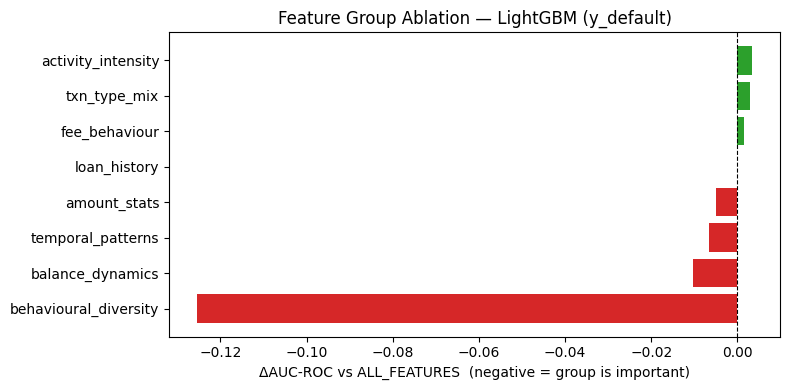

In [0]:
# Cell 12: Display ablation results
import matplotlib.pyplot as plt

drop_rows = abl_df[abl_df["condition"].str.startswith("DROP_")].copy()
drop_rows["group"] = drop_rows["condition"].str.replace("DROP_", "", regex=False)
drop_rows["delta"] = drop_rows["auc_roc"] - baseline_auc
drop_rows = drop_rows.sort_values("delta")   # most negative = most important

print(f"=== Ablation Results — {ablation_model} on y_default ===")
print(
    drop_rows[["group", "n_features", "auc_roc", "delta", "brier", "ece"]]
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if d < 0 else "#2ca02c" for d in drop_rows["delta"]]
ax.barh(drop_rows["group"], drop_rows["delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("\u0394AUC-ROC vs ALL_FEATURES  (negative = group is important)")
ax.set_title(f"Feature Group Ablation — {ablation_model} (y_default)")
plt.tight_layout()
plt.show()